In [1]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('.'))

from xso.parscans import run_xso_parscan

from cariaco_ssm_setup import model, model_setup, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup,
)

# -----------------------------------------------------------------------------
# Load observations
# -----------------------------------------------------------------------------
obs_vec, labels, bin_defs, monthly_df = load_cariaco_targets(regime='all')
print("Observation targets:")
for lab, val in zip(labels, obs_vec):
    print(f"  {lab:20s}: {val:.5f}")

# -----------------------------------------------------------------------------
# Tiny 2D scan: 3 x 3 = 9 runs on KsZ × fish_rate
# -----------------------------------------------------------------------------
p1_name = 'Grazing__KsZ'
p2_name = 'FishGrazing__rate'
p1_values = np.linspace(0.5, 3.0, 3)
p2_values = np.linspace(0.001, 0.01, 3)

print(f"\nRunning 3x3 scan on {p1_name} x {p2_name} ...")
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup',
    param_name=p1_name,
    param_values=p1_values,
    param_name2=p2_name,
    param_values2=p2_values,
    processes=4,
)

# -----------------------------------------------------------------------------
# Compute cost grid and extract best fit
# -----------------------------------------------------------------------------
cost_grid, model_grid = compute_cost_grid(
    scan_results,
    phyto_esd=phyto_esd,
    zoo_esd=zoo_esd,
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    avg_window=500,
    dim1_name=p1_name,
    dim2_name=p2_name,
)
print("\nCost grid:")
print(cost_grid)

best = find_best_fit(cost_grid, model_grid, scan_results, p1_name, p2_name)
print(f"\nBest fit:")
print(f"  {p1_name} = {best['val1']:.4f}")
print(f"  {p2_name} = {best['val2']:.4f}")
print(f"  cost      = {best['cost']:.4f}")
print(f"  model_vec = {best['model_vec']}")

# -----------------------------------------------------------------------------
# Test default-param lookup
# -----------------------------------------------------------------------------
print(f"\nDefault {p1_name} from setup: {get_default_from_setup(model_setup, p1_name)}")
print(f"Default {p2_name} from setup: {get_default_from_setup(model_setup, p2_name)}")

PROGRESS: Completed 3/3 outer points. (Grazing__KsZ = 3.0).

2D Scan complete. Total Time taken: 5.89102 seconds.

Cost grid:
[[0.95994294 0.9643601  0.96941665]
 [1.8901315  1.88375312 1.87763677]
 [2.68493742 2.68443403 2.68365007]]

Best fit:
  Grazing__KsZ = 0.5000
  FishGrazing__rate = 0.0010
  cost      = 0.9599
  model_vec = [2.64020512e-01 1.41880275e-01 6.18227879e-13 4.60330122e-02
 2.07323471e-03 8.30345916e-01]

Default Grazing__KsZ from setup: 3.0
Default FishGrazing__rate from setup: 0.005


In [3]:
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    param_name='Grazing__KsZ', param_values=np.array([1.0, 2.0]),
    param_name2='FishGrazing__rate', param_values2=np.array([0.001, 0.01]),
    processes=4,
    fixed_overrides={'Inflow__FN': 4.0, 'Inflow__de': 35.0},
)
print(scan_results.coords)  # Should show Inflow__FN=4.0 and Inflow__de=35.0

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup' from 'cariaco_ssm_setup'...
Validation successful. Proceeding with scan.
--------------------------------


ValueError: fixed_overrides contains parameter(s) also being scanned: ['Inflow__FN']. A parameter cannot be both scanned and held fixed.

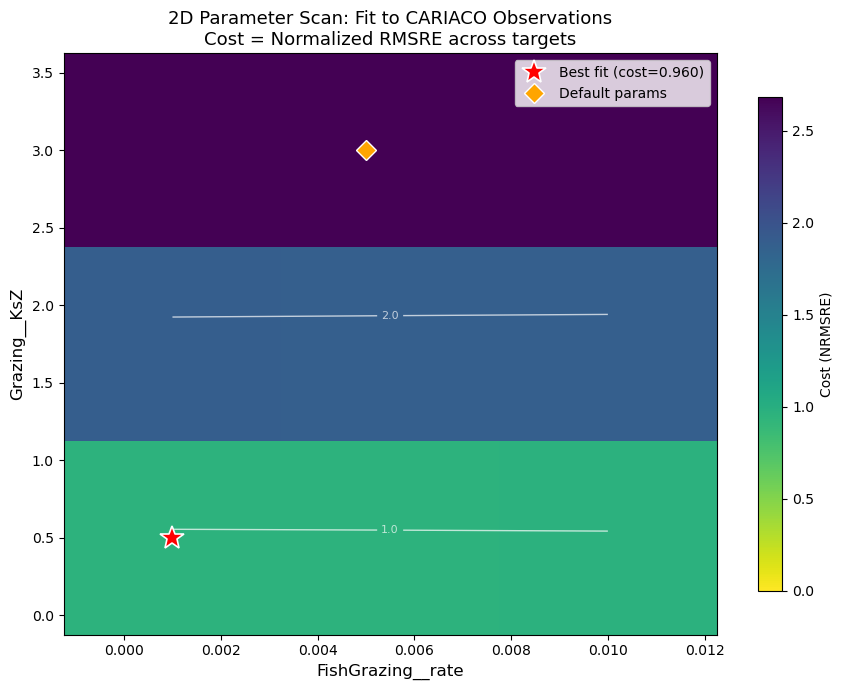

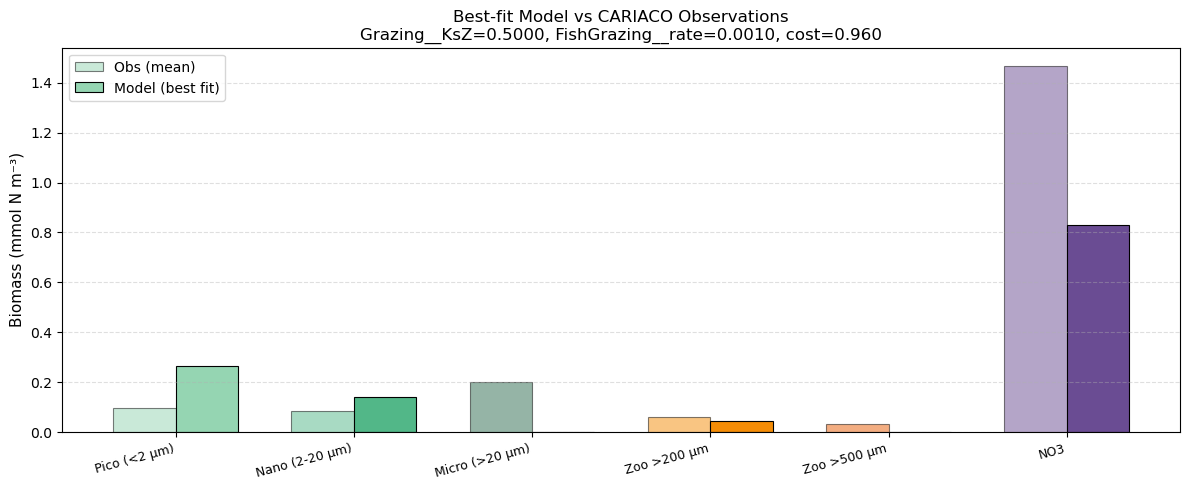

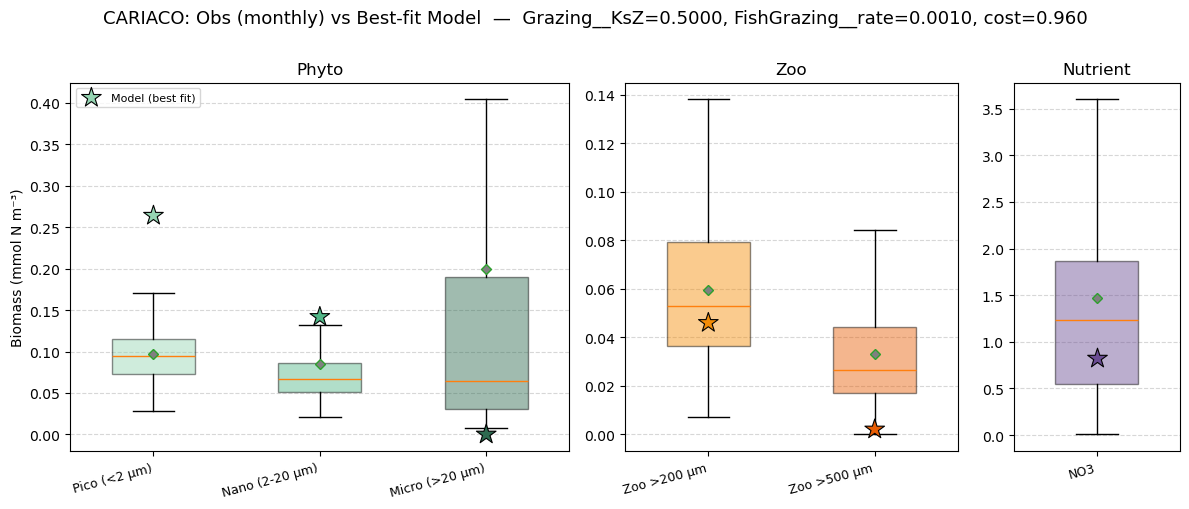


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 0.9599
     Component  Obs_Mean  Model_BestFit   Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        0.26402 2.72248    172.24785
Nano (2-20 µm)   0.08512        0.14188 1.66691     66.69091
Micro (>20 µm)   0.19977        0.00000 0.00000   -100.00000
   Zoo >200 µm   0.05938        0.04603 0.77527    -22.47348
   Zoo >500 µm   0.03302        0.00207 0.06278    -93.72180
           NO3   1.46705        0.83035 0.56600    -43.40037


In [3]:
import matplotlib.pyplot as plt
from parscan_plots import (
    plot_cost_heatmap,
    plot_model_vs_obs_bars,
    plot_model_vs_obs_boxplots,
    summarize_best_fit,
)

# Build default dict for heatmap marker
default = {
    'val1': get_default_from_setup(model_setup, p1_name),
    'val2': get_default_from_setup(model_setup, p2_name),
}

# Build title_info string for bar / boxplot titles
title_info = (f"{p1_name}={best['val1']:.4f}, "
              f"{p2_name}={best['val2']:.4f}, "
              f"cost={best['cost']:.3f}")

# 1. Cost heatmap
fig1 = plot_cost_heatmap(
    cost_grid=cost_grid,
    vals1=p1_values,
    vals2=p2_values,
    p1_label=p1_name,
    p2_label=p2_name,
    best=best,
    default=default,
)
plt.show()

# 2. Bar comparison
fig2 = plot_model_vs_obs_bars(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    title_info=title_info,
)
plt.show()

# 3. Boxplots with monthly obs variance
fig3 = plot_model_vs_obs_boxplots(
    model_vec=best['model_vec'],
    monthly_df=monthly_df,
    bin_definitions=bin_defs,
    title_info=title_info,
)
plt.show()

# 4. Numerical summary
summary = summarize_best_fit(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    labels=labels,
    cost=best['cost'],
)